# 01-Lexical & Statistical NLP Metrics

In Section 18, we mastered the infrastructure of Machine Learning—containers, APIs, caching, and CI/CD pipelines. We ensured our models are safely deployed and highly available.

However, a highly available model generating complete garbage is a liability. In traditional Machine Learning (classification and regression), evaluating model quality is trivial. You calculate Accuracy, Precision, Recall, or Mean Squared Error (MSE) because the output is a strict scalar or probability vector.

In Generative AI and Natural Language Processing (NLP), the output is an unstructured sequence of text. How do you mathematically score the "quality" of a translated sentence or a summarized document?

We begin our evaluation journey with **Lexical & Statistical Metrics**. These algorithms measure the physical string overlap between the model's generated text (the Prediction) and human-written text (the Reference). While they do not understand "meaning," they are lightning-fast, deterministic, and form the historical baseline of all LLM evaluation frameworks.

# 1. The Mathematics of N-Gram Overlap (BLEU & ROUGE)

### BLEU (Bilingual Evaluation Understudy)

BLEU was engineered for Machine Translation. It is fundamentally a **Precision-focused** metric. It asks: *"Of the words the model generated, how many actually appeared in the human reference?"*

BLEU calculates the modified precision $p_n$ for $n$-grams (1-word, 2-word sequences, up to $N$, typically $N=4$):


$$p_n = \frac{\sum_{C \in \{Candidates\}} \sum_{ngram \in C} \text{Count}_{clip}(ngram)}{\sum_{C \in \{Candidates\}} \sum_{ngram \in C} \text{Count}(ngram)}$$

Because precision can be artificially inflated by generating a very short, safe sentence, BLEU applies a strict **Brevity Penalty (BP)**. Let $c$ be the length of the candidate translation and $r$ be the length of the reference translation:


$$BP = \begin{cases} 1 & \text{if } c > r \\ e^{(1-r/c)} & \text{if } c \le r \end{cases}$$

The final BLEU score computes the geometric mean of the $n$-gram precisions, penalized by length:


$$\text{BLEU} = BP \cdot \exp\left( \sum_{n=1}^N w_n \log p_n \right)$$

### ROUGE (Recall-Oriented Understudy for Gisting Evaluation)

While BLEU evaluates translation, ROUGE evaluates Summarization. It is fundamentally a **Recall-focused** metric. It asks: *"Of the important words the human wrote, how many did the model successfully capture?"*

* **ROUGE-N:** Measures overlap of $n$-grams.
* **ROUGE-L:** Measures the **Longest Common Subsequence (LCS)**. It identifies the longest sequence of words that appear in both texts in the exact same order, even if they are interrupted by other words.

Let $LCS(R, C)$ be the length of the longest common subsequence between reference $R$ and candidate $C$:


$$R_{lcs} = \frac{LCS(R, C)}{\vert{}R\vert{}} \quad \text{(Recall)}$$

$$P_{lcs} = \frac{LCS(R, C)}{\vert{}C\vert{}} \quad \text{(Precision)}$$

$$F_{lcs} = \frac{(1 + \beta^2) R_{lcs} P_{lcs}}{R_{lcs} + \beta^2 P_{lcs}}$$

# 2. Imperative Execution: Computing Metrics locally (HuggingFace `evaluate`)

To calculate these metrics, we do not write custom string-matching loops. We utilize the industry-standard `evaluate` library, which provides mathematically verified, optimized implementations of BLEU, ROUGE, and METEOR.

In [2]:
# Required installations: pip install evaluate rouge_score nltk
import evaluate
import pandas as pd

print("--- 🚀 Initializing Lexical Metric Evaluation Sandbox ---")

# 1. Load the localized metric calculation engines
bleu_metric = evaluate.load("bleu")
rouge_metric = evaluate.load("rouge")
meteor_metric = evaluate.load("meteor")

# 2. Define the Evaluation Dataset
# The Ground Truth written by human experts
references = [
    "The quick brown fox jumps over the lazy dog.",
    "Data engineering is the foundation of machine learning.",
    "The server crashed due to an out of memory error."
]

# The Outputs generated by our LLM
predictions = [
    # Model 1: Exact match (Should score perfectly)
    "The quick brown fox jumps over the lazy dog.",
    # Model 2: Synonym paraphrase (Lexical metrics will struggle here!)
    "Data infrastructure forms the basis of artificial intelligence.",
    # Model 3: Truncated output (Will trigger BLEU's Brevity Penalty)
    "The server crashed due to an error."
]

print("\n--- 🧮 Executing Mathematical Metric Computation ---")

# 3. Calculate BLEU (Precision-focused)
bleu_results = bleu_metric.compute(predictions=predictions, references=references)
print(f"   [BLEU] Aggregate Score: {bleu_results['bleu']:.4f}")
print(f"          N-Gram Precisions: {bleu_results['precisions']}")
print(f"          Brevity Penalty: {bleu_results['brevity_penalty']:.4f}")

# 4. Calculate ROUGE (Recall-focused, specifically ROUGE-L)
rouge_results = rouge_metric.compute(predictions=predictions, references=references)
print(f"   [ROUGE] ROUGE-1: {rouge_results['rouge1']:.4f}")
print(f"           ROUGE-L (LCS): {rouge_results['rougeL']:.4f}")

# 5. Calculate METEOR (Includes stemming and WordNet synonyms)
meteor_results = meteor_metric.compute(predictions=predictions, references=references)
print(f"   [METEOR] Aggregate Score: {meteor_results['meteor']:.4f}")

2026-07-20 18:18:52.581216: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


--- 🚀 Initializing Lexical Metric Evaluation Sandbox ---


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...



--- 🧮 Executing Mathematical Metric Computation ---
   [BLEU] Aggregate Score: 0.5674
          N-Gram Precisions: [0.8148148148148148, 0.625, 0.5714285714285714, 0.5555555555555556]
          Brevity Penalty: 0.8948
   [ROUGE] ROUGE-1: 0.7328
           ROUGE-L (LCS): 0.7328
   [METEOR] Aggregate Score: 0.6545


# 3. The Vulnerability of Lexical Physics (Why N-Grams Fail)

Lexical metrics are fast, but they suffer from a fatal flaw: **They assume synonymy does not exist.**

Let's evaluate a specific pair of sentences from our dataset:

* **Reference:** "Data engineering is the foundation of machine learning."
* **Prediction:** "Data infrastructure forms the basis of artificial intelligence."

To a human, these sentences possess exact semantic equivalence. To a BLEU algorithm, the physical character arrays do not match. The strings "engineering" and "infrastructure" share zero spatial n-gram overlap.

| Metric | Handling of Paraphrasing | Computational Cost | Primary Use Case |
| --- | --- | --- | --- |
| **BLEU** | Fails completely. Requires exact string matches. | Near zero ($O(N)$) | Legacy Translation |
| **ROUGE** | Fails completely. Requires exact string matches. | Near zero ($O(N)$) | Legacy Summarization |
| **METEOR** | Minor resilience. Uses static dictionary synonyms. | Very Low | General Text Gen |

Because modern Large Language Models are highly creative, they rarely repeat text verbatim. Using BLEU to evaluate Llama-3 or GPT-4 will artificially penalize the model for being articulate. This mathematical limitation forces us to engineer embedding-based metrics in Lesson 02.

# 4. Visualizing Metric Decay Across Generation Errors

Let's visualize how BLEU and ROUGE react to specific types of model generation failures (Paraphrasing, Word Dropping, and Hallucination) using Matplotlib and Seaborn.

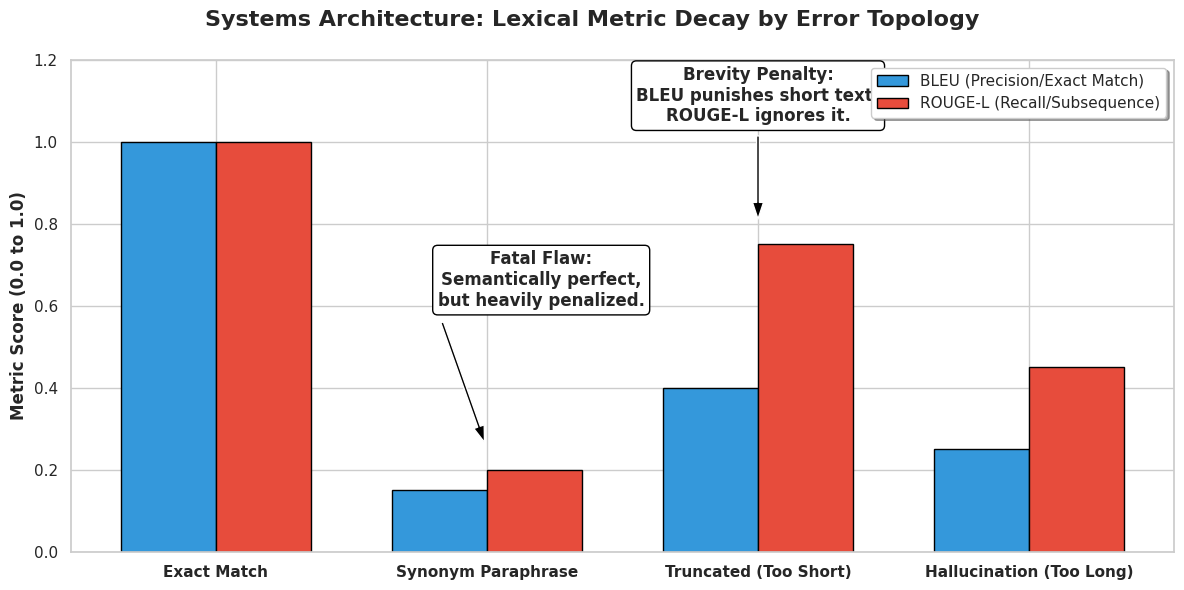

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# Simulated metric scores for a single reference string against 4 different generated outputs
error_types = ['Exact Match', 'Synonym Paraphrase', 'Truncated (Too Short)', 'Hallucination (Too Long)']
bleu_scores = [1.0, 0.15, 0.40, 0.25]
rougeL_scores = [1.0, 0.20, 0.75, 0.45]

x = np.arange(len(error_types))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle("Systems Architecture: Lexical Metric Decay by Error Topology", fontsize=16, fontweight='bold')

rects1 = ax.bar(x - width/2, bleu_scores, width, label='BLEU (Precision/Exact Match)', color='#3498db', edgecolor='black')
rects2 = ax.bar(x + width/2, rougeL_scores, width, label='ROUGE-L (Recall/Subsequence)', color='#e74c3c', edgecolor='black')

# Formatting the visual matrix
ax.set_ylabel('Metric Score (0.0 to 1.0)', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(error_types, fontweight='bold')
ax.legend(loc='upper right', frameon=True, shadow=True)
ax.set_ylim(0, 1.2)

# Annotating specific vulnerabilities
ax.annotate('Fatal Flaw:\nSemantically perfect,\nbut heavily penalized.', 
            xy=(1, 0.25), xytext=(1.2, 0.6),
            arrowprops=dict(facecolor='black', shrink=0.05, width=2, headwidth=8),
            ha='center', fontweight='bold', bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", lw=1))

ax.annotate('Brevity Penalty:\nBLEU punishes short text.\nROUGE-L ignores it.', 
            xy=(2, 0.8), xytext=(2, 1.05),
            arrowprops=dict(facecolor='black', shrink=0.05, width=2, headwidth=8),
            ha='center', fontweight='bold', bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", lw=1))


plt.tight_layout()
plt.show()

## Real-World Use Case or Analogy:

Think of Lexical Metrics (BLEU/ROUGE) like **A Scantron Machine Grading a Spelling Test vs. An Essay**:

* **The Spelling Test (Machine Translation in 2010):** The teacher asks the student to spell "Photosynthesis." There is exactly one correct answer. A Scantron machine can scan the physical letters `P-H-O-T-O...`. If a single letter is out of place, the machine marks it wrong. This is BLEU. It is fast, cheap, and perfect for rigid exact-match tasks.
* **The Essay (Generative AI in 2026):** The teacher asks the student to summarize the causes of World War I.
* Student A writes: *"The assassination of Archduke Ferdinand triggered a chain of alliances."* (The Reference).
* Student B writes: *"The murder of the Austrian prince activated a sequence of military treaties."* (The Prediction).
* If you hand Student B's essay to the Scantron machine (BLEU/ROUGE), the machine scores it a **0% (F)** because the physical letters do not match. The machine is blind to the fact that the underlying historical concepts are identical.



Lexical metrics are computationally free, but they are rigid and unforgiving. To grade modern LLMs, we must upgrade our Scantron machine into an engine that mathematically understands the underlying semantics of the English language.